In [2]:
from torch.utils.data import (
    Dataset,
    DataLoader,
    ConcatDataset,
    DistributedSampler,
    RandomSampler,
    dataloader
)
from os import path as osp
import torch
from megadepth import MegaDepthDataset
from tqdm import tqdm
import h5py

gen_train_set = True
list_name = 'train_list' if gen_train_set else 'test_list_short'

# list_name = 'val_list'
scene_info = 'scene_info_0.1_0.7' #scene_info_0.1_0.7
scene_list_path = f'/media/rex/rex_4t_2/data/megadepth/train-data/megadepth_indices/trainvaltest_list/{list_name}.txt'
npz_dir = f'/home/rex/Downloads/train-data-20250903T175239Z-1-002/train-data/megadepth_indices/{scene_info}'
megadepth_root = '/media/rex/rex_4t/data/megadepth'
# depth_path = '/media/rex/rex_4t/data/megadepth/phoenix/S6/zl548/MegaDepth_v1'

with open(scene_list_path, 'r') as f:
    npz_names = [name.split()[0] for name in f.readlines()]
npz_names = [f'{n}.npz' for n in npz_names]
datasets = []

for npz_name in tqdm(npz_names):
    npz_path = osp.join(npz_dir, npz_name)

    datasets.append(MegaDepthDataset(megadepth_root,
                        npz_path,
                        mode='test',
                        min_overlap_score=0,
                        img_resize=640,
                        df=None,
                        img_padding=True,
                        depth_padding=True,
                        augment_fn=None,
                        coarse_scale=0.125,
                        fp16 = False,
                        ))
    
alldata = ConcatDataset(datasets)

ignore_list = ["1589", "0183", "0331", "0101", "0189"]


  0%|          | 0/368 [00:00<?, ?it/s]

100%|██████████| 368/368 [00:12<00:00, 29.54it/s]


In [3]:
len(alldata)

8862673

In [4]:
batch = alldata[0]

In [5]:
batch.keys()

dict_keys(['image0', 'depth0', 'image1', 'depth1', 'T_0to1', 'T_1to0', 'K0', 'K1', 'scale0', 'scale1', 'dataset_name', 'scene_id', 'pair_id', 'pair_names', 'mask0', 'mask1'])

In [6]:
unique_num = 0
path_list = []
intrinsics = []
poses = []
for i in range(0, len(datasets)):
    oneset = datasets[i]
    if oneset.scene_id.split('_')[0] in ignore_list:
        print('skip ',oneset.scene_id)
        continue
    idx_list = []
    # path_list = []
    for (idx0, idx1), overlap_score, central_matches in oneset.pair_infos:
        # if overlap_score>=0.4:
            if idx0 not in idx_list:
                idx_list.append(idx0)
                path_list.append(osp.join(oneset.root_dir, oneset.scene_info['image_paths'][idx0]))
                intrinsics.append(oneset.scene_info['intrinsics'][idx0].copy())
                poses.append(oneset.scene_info['poses'][idx0].copy())
            if idx1 not in idx_list:
                idx_list.append(idx1)
                path_list.append(osp.join(oneset.root_dir, oneset.scene_info['image_paths'][idx1]))
                intrinsics.append(oneset.scene_info['intrinsics'][idx1].copy())
                poses.append(oneset.scene_info['poses'][idx1].copy())
    unique_num += len(idx_list)
print(unique_num)
# print(intrinsics)


# print(oneset.scene_info['image_paths'][idx0])
        

skip  0183_0
skip  0331_0
skip  0101_0
skip  0183_0
skip  0331_0
skip  0183_0
skip  0189_0
skip  0189_0
skip  0189_0
skip  0101_0
skip  0331_0
skip  0101_0
167909


In [7]:
def duplicate_indexes(lst):
    seen = set()
    dup_idx = []
    for i, v in enumerate(lst):
        if v in seen:
            dup_idx.append(i)
        else:
            seen.add(v)
    return dup_idx
def delete_indices(lst, indices):
    for i in sorted(indices, reverse=True):
        del lst[i]
    return lst

dupli_idx = duplicate_indexes(path_list)
path_list = delete_indices(path_list, dupli_idx)
intrinsics = delete_indices(intrinsics, dupli_idx)
poses = delete_indices(poses, dupli_idx)
print(len(path_list))


64711


In [8]:
from random_motion import generate_transformed_images, write_timestamp
import os
import cv2
import numpy as np
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
pbar = tqdm(total=len(path_list))
def worker(i, im_path):
    save_dir = im_path.replace('rex_4t','rex_4t_2').replace('Undistorted_SfM', 'motion_upsampled').split('.')[0]
    save_dirs.append(save_dir)
    depth_dir = im_path.replace('Undistorted_SfM','phoenix/S6/zl548/MegaDepth_v1').replace('images','dense0/depths').split('.')[0] + '.h5'
    os.makedirs(save_dir, exist_ok = True)
    im_save_dir = osp.join(save_dir,'imgs')
    os.makedirs(im_save_dir, exist_ok = True)

    # Process images
    img = cv2.imread(im_path)  # replace with your image
    
    frames, crop1, crop2, scale_y, scale_x = generate_transformed_images(img, wt, ht, duration=duration, fps=fps, max_shift_factor=0.035, max_angle=np.pi/48)
    cv2.imwrite(osp.join(save_dir,'frame.png'), frames[0])

    # Process depth the same croping and resizing operation from generate_transformed_images
    # depth_save_dir = osp.join(save_dir, 'depth')
    with h5py.File(depth_dir, 'r') as f:
        depth = f['depth'][:]
        depth_croped = crop_img(depth, crop1)
        depth_croped = crop_img(depth_croped, crop2)
        depth_croped = cv2.resize(depth_croped,(wt, ht), interpolation=cv2.INTER_NEAREST_EXACT)
    with h5py.File(osp.join(save_dir, 'depth.h5'), 'w') as f:
        f.create_dataset("depth", data=depth_croped)
    # print(f"Generated {len(frames)} cropped grayscale frames at 500Hz")

    # Intrinsic multiplier 
    b_x = crop1[0]+crop2[0]
    b_y = crop1[1]+crop2[1]
    intr = intrinsics[i]
    intr[0,-1] -= b_x
    intr[1,-1] -= b_y
    intr[0] *= scale_x
    intr[1] *= scale_y
    
    np.savetxt(osp.join(save_dir, 'intrinsics.txt'), intr)

    np.savetxt(osp.join(save_dir, 'pose.txt'), poses[i])
    # show a few sample frames
    for i in range(0, len(frames), 1):
        cv2.imwrite(osp.join(im_save_dir,"frame%05i.png"%i), frames[i])
    write_timestamp(save_dir, duration, fps)
    pbar.update(1)

# Step1: generate upsampled images with 4 dof motion

def crop_img(img, crop):
    x1, y1, x2, y2 = crop
    return img[y1:y2+1, x1:x2+1]
max_worker = 8
fps = 530
duration = 0.3
wt=640
ht=360
save_folder = 'motion_upsampled'
save_dirs = []
for im_path in path_list:
    save_dir = im_path.replace('rex_4t','rex_4t_2').replace('Undistorted_SfM', 'motion_upsampled').split('.')[0]
    save_dirs.append(save_dir)


# index = range(len(path_list))
# with ThreadPoolExecutor(max_workers=max_worker) as executor:
#     results = list(executor.map(worker, index, path_list))


  0%|          | 0/64711 [00:00<?, ?it/s]

In [12]:
save_dirs[0]

'/media/rex/rex_4t_2/data/megadepth/motion_upsampled/0022/images/427154679_de14c315f4_o'

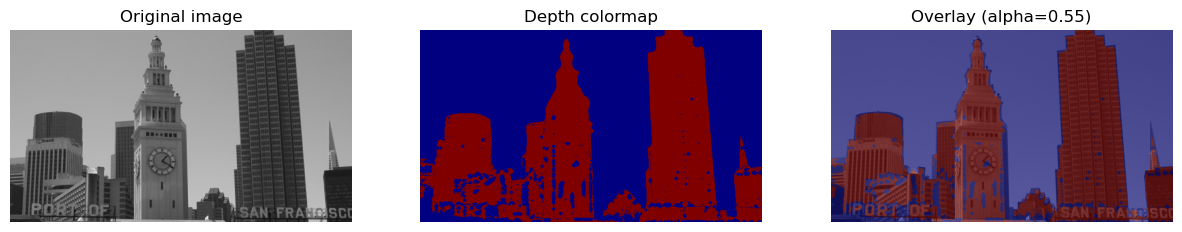

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def overlay_depth_on_image(image, depth,
                           depth_vmin=None, depth_vmax=None,
                           colormap=cv2.COLORMAP_JET,
                           alpha=0.6,
                           invalid_color=(0, 0, 0)):
    """
    image: HxWx3 uint8 BGR or RGB (if using matplotlib, prefer RGB)
    depth: HxW single-channel (float or uint) depth map. May contain NaN or Inf.
    depth_vmin, depth_vmax: clip/scale range for depth coloring. If None, computed from valid depth.
    colormap: OpenCV colormap (e.g., cv2.COLORMAP_JET)
    alpha: blending factor for overlay (0..1). 0 => original image, 1 => colormap only.
    invalid_color: RGB triplet used where depth is invalid (before applying colormap)
    returns: overlay_rgb (HxWx3 uint8), depth_colormap (HxWx3 uint8)
    """

    # Copy inputs
    img = image.copy()
    if img.dtype != np.uint8:
        raise ValueError("image must be uint8")

    # Ensure depth is float32
    d = depth.astype(np.float32)

    # Mask invalid depth
    valid_mask = np.isfinite(d)
    if not valid_mask.any():
        raise ValueError("depth contains no finite values")

    # Determine vmin/vmax
    if depth_vmin is None:
        depth_vmin = float(np.nanmin(d[valid_mask]))
    if depth_vmax is None:
        depth_vmax = float(np.nanmax(d[valid_mask]))
    if depth_vmin == depth_vmax:
        depth_vmax = depth_vmin + 1e-6

    # Clip and normalize to 0..255
    d_clip = np.clip(d, depth_vmin, depth_vmax)
    d_norm = (d_clip - depth_vmin) / (depth_vmax - depth_vmin)  # 0..1
    d_8u = (d_norm * 255).astype(np.uint8)

    # Fill invalid with 0 (or any constant). Later we can recolor those pixels if desired.
    d_8u[~valid_mask] = 0

    # Apply colormap (OpenCV expects single-channel 8-bit)
    depth_color_bgr = cv2.applyColorMap(d_8u, colormap)  # returns BGR uint8

    # Optionally set invalid pixels to a specific color (e.g., black)
    if invalid_color is not None:
        # invalid_color is RGB; convert to BGR for OpenCV image
        inv_bgr = tuple(int(x) for x in invalid_color[::-1])
        depth_color_bgr[~valid_mask] = inv_bgr

    # Convert input image to BGR if user passed RGB (detect by heuristic: check mean)
    # (We will assume user knows input format. If using plt.imshow, convert to RGB below.)
    # Blend: ensure both are BGR uint8
    if img.shape[2] == 3:
        img_bgr = img
    else:
        raise ValueError("image must be HxWx3")

    overlay_bgr = cv2.addWeighted(depth_color_bgr, alpha, img_bgr, 1 - alpha, 0)

    # Convert BGR -> RGB for matplotlib display
    depth_color_rgb = cv2.cvtColor(depth_color_bgr, cv2.COLOR_BGR2RGB)
    overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

    return overlay_rgb, depth_color_rgb

test = '/media/rex/rex_4t_2/data/megadepth/motion_upsampled/0064/images/541615685_a0b8c03c14_o'
depth_path = osp.join(test, 'depth.h5')
imgs_path = osp.join(test, 'imgs/frame00000.png')

image = cv2.imread(imgs_path)

with h5py.File(depth_path, 'r') as f:
    depth = f['depth'][:]

overlay, depth_colormap = overlay_depth_on_image(image, depth, depth_vmin=0.5, depth_vmax=6.0, alpha=0.55)

# Plot side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(depth_colormap)
axes[1].set_title("Depth colormap")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Overlay (alpha=0.55)")
axes[2].axis("off")

plt.show()

In [ ]:
# Step2 generate event with vid2e 
# python batch_generate.py -i /media/rex/rex_4t/data/megadepth/motion_upsampled

In [14]:
# Step3 convert event to multiscale input and compile events, pose, intrinsic, image to a single h5.
import sys
sys.path.append('/home/rex/Desktop/github/heterogeneous_matching/')
sys.path.append('/home/rex/Desktop/github/heterogeneous_matching/dataset')
from representations.adaptive_interval import Adaptive_interval
from representations.visualize_bluewhite import EventVis
from prepare_m3ed import stack_pos_neg, get_event_polarity, dataset_config
import torch.nn.functional as F

cfg = dataset_config
save_raw_events = True

print(dataset_config)

def worker_compile_all(dir):
    event_file = osp.join(dir, 'event.h5')
    intrinsic_file = osp.join(dir, 'intrinsics.txt')
    depth_file = osp.join(dir, 'depth.h5')
    pose_file = osp.join(dir, 'pose.txt')
    image_file = osp.join(dir, 'frame.png')
    dst_file = dir.replace('motion_upsampled', 'e_mega') + '.h5'
    os.makedirs(osp.dirname(dst_file), exist_ok=True)
    if os.path.isfile(dst_file) or not os.path.isfile(event_file): 
        # print('skip dst', dst_file)
        return
    # Process event

    print('processing ',dir)
    
    with h5py.File(event_file, 'r') as f:
        t_all = f['t'][:].copy()
        
        np.searchsorted(t_all,30*1e6)

        stop_index = np.searchsorted(t_all,30*1e6) #-1 #np.searchsorted(t_all, cfg['event_interval_ms']*1e6)
        event = {'x':torch.from_numpy(f['x'][:stop_index].copy().astype(float)).to(torch.float32),
                'y': torch.from_numpy(f['y'][:stop_index].copy().astype(float)).to(torch.float32),
                't': torch.from_numpy(f['t'][:stop_index].copy().astype(float)).to(torch.float32),
                'p': torch.from_numpy(f['p'][:stop_index].copy().astype(float)*2-1).to(torch.float32)
                }
        converter = EventVis((3, cfg['target_res'][0], cfg['target_res'][1]), classic=True)
        vis = converter.convert(event)
        from PIL import Image
        img = vis  # shape (3, H, W)
        img = np.transpose(img.numpy(), (1, 2, 0))  # -> (H, W, 3)

        # If values are in [0,1], scale to [0,255]
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)

        Image.fromarray(img).save(os.path.join(dst_file.replace('h5','png')))
    
    # if not save_raw_events:
    #     event_voxel = Adaptive_interval((cfg['num_bins'],ht,wt),normalize=False)
    #     event_po = get_event_polarity(event, polarity=1)
    #     event_ne = get_event_polarity(event, polarity=-1)
    #     if len(event_po['t'])<=1 or len(event_ne['t'])<=1:
    #         print('bad event seq', event_file)
    #         return
    #     data_event_pos = event_voxel.convert(event_po)
    #     event_voxel_neg = Adaptive_interval((cfg['num_bins'],ht,wt),normalize=False)
    #     data_event_neg = event_voxel_neg.convert(event_ne)

    #     data_event = stack_pos_neg(data_event_pos, data_event_neg)
    #     data_event_rec = F.interpolate(data_event.unsqueeze(0).float(),
    #                                     size=cfg['target_res'],
    #                                     mode='nearest'
    #                                     ).squeeze(0)

    # # Load pose & intrinsics
    # pose = np.loadtxt(pose_file)
    # intrinsic = np.loadtxt(intrinsic_file)

    # # Load image & depth
    # image = cv2.imread(image_file, cv2.IMREAD_GRAYSCALE)

    # # print(image.shape)
    # with h5py.File(depth_file, 'r') as f:
    #     depth = f['depth'][:]

    # # Write data
    # with h5py.File(dst_file, 'w') as f:
    #     compression = 'gzip' #'lzf'
    #     if not save_raw_events:
    #         f.create_dataset('event',data=data_event_rec,dtype=np.float32, compression=compression)
    #     else:
    #         f.create_dataset('event/x',data=event['x'],dtype=np.int32, compression=compression)
    #         f.create_dataset('event/y',data=event['y'],dtype=np.int32, compression=compression)
    #         f.create_dataset('event/t',data=event['t'],dtype=np.int64, compression=compression)
    #         f.create_dataset('event/p',data=event['p'],dtype=np.int8, compression=compression)
    #     f.create_dataset('image',data=image,dtype=np.uint16, compression=compression)
    #     f.create_dataset('depth',data=depth,dtype=np.float32, compression=compression)
    #     f.create_dataset('pose',data=pose,dtype=np.float32, compression=compression)
    #     f.create_dataset('K',data=intrinsic,dtype=np.float32, compression=compression)

with ThreadPoolExecutor(max_workers=max_worker) as executor:
    results = list(executor.map(worker_compile_all, save_dirs))

    

{'root_dir': '/media/rex/rex_4t/data/m3ed', 'save_dir': '/media/rex/rex_4t/data/hetero_m3ed', 'shape': [720, 1280], 'target_res': [360, 640], 'num_bins': 10, 'event_interval_ms': 256, 'interval_tolerance': 0.3, 'sample_interval': [1000000.0, 2000000.0], 'seed': 42, 'valid_img_margin': 20000.0, 'event_min_number': 1000000, 'min_trans': 0.0, 'rot_range': [5, 40], 'max_worker': 6}
processing  /media/rex/rex_4t_2/data/megadepth/motion_upsampled/0446/images/5122787062_7ef463a806_o
processing  /media/rex/rex_4t_2/data/megadepth/motion_upsampled/0446/images/8583256543_96562c14f2_o
processing  /media/rex/rex_4t_2/data/megadepth/motion_upsampled/0446/images/14130316691_955a61fea8_b
processing  /media/rex/rex_4t_2/data/megadepth/motion_upsampled/0446/images/2558497397_c313f2125e_o
processing  /media/rex/rex_4t_2/data/megadepth/motion_upsampled/0446/images/2794664963_9aba9da57a_b
processing  /media/rex/rex_4t_2/data/megadepth/motion_upsampled/0446/images/2970418137_4e62fb569e_o
processing  /media

KeyboardInterrupt: 

In [15]:
save_dirs[0]

'/media/rex/rex_4t_2/data/megadepth/motion_upsampled/0022/images/427154679_de14c315f4_o'

In [11]:
# Sanity Check
no_file_seqs = []
no_enough_events = []

def worker_check_all(dir):
    dst_file = dir.replace('motion_upsampled', 'event_megadepth/e_mega') + '.h5'
    if not os.path.isfile(dst_file): 
        no_file_seqs.append(dst_file)
        print('no file', dst_file)
        return
    # event_file = osp.join(dir, 'event.h5')
    # with h5py.File(event_file, 'r') as f:
    #     t_all = f['t'][:].copy()
    #     if len(t_all)<10000:
    #         no_enough_events.append(dir)
    #         print('less than 10000 event', event_file)

with ThreadPoolExecutor(max_workers=max_worker) as executor:
    results = list(executor.map(worker_check_all, save_dirs))